# Road Safety Open Dataset — Gran Bretagna

Dataset ufficiale del Department for Transport britannico sugli incidenti stradali
con feriti o morti su strade pubbliche, segnalati alla polizia tramite il sistema STATS19.

3 file collegati tramite `collision_index`: **Collisions**, **Vehicles**, **Casualties**.

**Periodo analizzato** : 2020-2024 (5 anni)

**Obiettivo**: prevedere la gravità di un incidente (`collision_severity`: Fatal / Serious / Slight).

*Fonte: [Road Safety Open Data — UK Government](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data)*


In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
import logging
logging.basicConfig(
        format='%(asctime)s\t%(levelname)s\t%(message)s',
        #filename='file_log.log',
        level=logging.INFO
        #level=logging.DEBUG
        )

In [3]:
pd.set_option('display.width', 10000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [4]:
df_casualty = pd.read_csv(os.path.join('.','data/dft-road-casualty-statistics-casualty-last-5-years.csv'))
df_collision = pd.read_csv(os.path.join('.','data/dft-road-casualty-statistics-collision-last-5-years.csv'))
df_vehicle = pd.read_csv(os.path.join('.', 'data/dft-road-casualty-statistics-vehicle-last-5-years.csv'))


C:\Users\Boom\AppData\Local\Temp\ipykernel_18704\2123800605.py:3: DtypeWarning: Columns (0: generic_make_model) have mixed types. Specify dtype option on import or set low_memory=False.
  df_vehicle = pd.read_csv(os.path.join('.', 'data/dft-road-casualty-statistics-vehicle-last-5-years.csv'))


## df_collision dataset

Ogni riga rappresenta UN incidente stradale.

**Chiave univoca:** `collision_index` = `collision_year` + `collision_ref_no`

In [5]:
df_collision.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2021170H10421,2021,170H10421,447098.000,532997.000,-1.271,54.690,17,3,2,...,0,0,2,1,2,E01011959,-1,0,0.294,0.706
1,2021170H11231,2021,170H11231,450486.000,533118.000,-1.218,54.691,17,3,2,...,0,0,1,2,2,E01011973,-1,0,0.017,0.983
2,2020170M11750,2020,170M11750,449694.000,519733.000,-1.233,54.570,17,3,2,...,0,0,1,1,2,E01012092,-1,0,0.129,0.871
3,2021170M31761,2021,170M31761,449744.000,514217.000,-1.233,54.521,17,3,1,...,0,0,2,1,2,E01032553,-1,0,0.183,0.817
4,2021170S10441,2021,170S10441,445971.000,520834.000,-1.290,54.581,17,3,3,...,0,13,2,1,1,E01012258,-1,0,0.016,0.984


#### TARGET: `collision_severity`
Rappresenta la gravità complessiva dell'incidente

| Valore | Label |
|---|---|
| 1 | Fatal |
| 2 | Serious |
| 3 | Slight |

*Fonte: [Road Safety Open Dataset Data Guide 2024](https://assets.publishing.service.gov.uk/media/691c6440e39a085bda43eed6/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx)*

A differenza di `casualty_severity` — che misura la gravità del singolo ferito
generando più righe per incidente — `collision_severity` mantiene una riga per
incidente, prendendo sempre il caso più grave tra i feriti coinvolti.

Di seguito le principali caratteristiche del dataset grezzo:

 **503.475 incidenti** totali, **44 colonne**
- Quasi tutte le colonne sono **complete** (503475 non-null)
- Le uniche eccezioni nel dataset grezzo:
  - `location_easting_osgr`, `location_northing_osgr`, `longitude`, `latitude` → **65 NaN** (503475 - 503410)
  - `local_authority_highway_current` → **80 NaN** (503475 - 503395)
- `collision_severity` (il nostro **target**) → **0 NaN**


In [6]:
df_collision.info()

<class 'pandas.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  str    
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  str    
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_severity                                503475 non-null  int64  
 9   number_of_vehic

In [7]:
"""
# Verifica: collision_severity è univoca per collision_index (una riga per incidente)

"""
df_collision['collision_index'].duplicated().sum()

np.int64(0)

## Definizione variabili per tipo

### 1. Drop delle variabili da escludere


Stabiliamo quali variabili escludere in partenza. L'informazione che offrono queste variabili è ritondante o superflua


In [5]:
target=['collision_severity']
index=['collision_index']
var_escludere=['enhanced_severity_collision','local_authority_district','local_authority_highway','local_authority_highway_current','first_road_number','second_road_number','junction_detail','road_type', \
               'pedestrian_crossing','lsoa_of_accident_location','trunk_road_flag', \
               'collision_injury_based','collision_adjusted_severity_serious','collision_adjusted_severity_slight','police_force','collision_ref_no',\
               'location_easting_osgr','location_northing_osgr','longitude','latitude','carriageway_hazards_historic'
]
var_categoriche=['collision_year','first_road_class','second_road_class','junction_detail_historic','pedestrian_crossing_physical_facilities_historic','light_conditions','day_of_week','date','time']
var_dummy=['junction_control','pedestrian_crossing_human_control_historic', 'weather_conditions','road_surface_conditions','special_conditions_at_site','carriageway_hazards','urban_or_rural_area','local_authority_ons_district', 'did_police_officer_attend_scene_of_accident']
var_numeriche=['speed_limit','number_of_vehicles','number_of_casualties']

#len(df_collision_clean.columns) - len(var_escludere) - len(var_categoriche) - len(var_dummy) - len(var_numeriche) - len(target) - len(index)


In [6]:
#drop delle colonne delle variabili da escludere
df_collision_ex=df_collision.drop(var_escludere,axis=1)
df_collision_ex.shape

(503475, 23)

In [9]:
# verifica dell'assenza di colonne interamente nulle
df_collision_ex.columns[df_collision_ex.isna().all()]

Index([], dtype='str')

## Data cleaning

### 2. Sostituzione dei valori -1 con NaN
I valori -1 nel dataset indicano dati mancanti.
Li sostituiamo con `NaN`per gestirli correttamente nei passaggi successivi, in particolare per identificare le osservazioni con un’elevata presenza di valori mancanti

In [7]:
df_collision_clean = df_collision_ex.copy()

# int64 (numpy) non ammette NaN → convertiamo a Int64 (pandas, maiuscolo) che lo supporta
int_cols = df_collision_clean.select_dtypes(include='int64').columns
df_collision_clean[int_cols] = df_collision_clean[int_cols].replace(-1, pd.NA).astype("Int64")

# float supporta NaN nativamente, nessuna conversione di tipo necessaria
float_cols = df_collision_clean.select_dtypes(include='float64').columns
df_collision_clean[float_cols] = df_collision_clean[float_cols].replace(-1, np.nan)

# nelle colonne testo il -1 è codificato come stringa '-1' → sostituiamo con pd.NA (mancante per stringhe)
str_cols = df_collision_clean.select_dtypes(include='object').columns
df_collision_clean[str_cols] = df_collision_clean[str_cols].replace('-1', pd.NA)


C:\Users\Boom\AppData\Local\Temp\ipykernel_18704\3541517829.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_collision_clean.select_dtypes(include='object').columns


In [8]:
# verifica dei NaN dopo la sostituzione
df_collision_clean.isna().sum().sort_values(ascending=False)

junction_control                                    211708
special_conditions_at_site                           63730
pedestrian_crossing_human_control_historic           63180
pedestrian_crossing_physical_facilities_historic     63144
junction_detail_historic                             59607
second_road_class                                    11477
carriageway_hazards                                   4741
road_surface_conditions                               3209
light_conditions                                        19
speed_limit                                             15
weather_conditions                                      13
urban_or_rural_area                                      8
did_police_officer_attend_scene_of_accident              1
collision_index                                          0
collision_year                                           0
day_of_week                                              0
date                                                    

### 3. Imputazione

In [9]:
missing = df_collision_clean.isna().sum().sort_values(ascending=False)
missing[missing > 0]

junction_control                                    211708
special_conditions_at_site                           63730
pedestrian_crossing_human_control_historic           63180
pedestrian_crossing_physical_facilities_historic     63144
junction_detail_historic                             59607
second_road_class                                    11477
carriageway_hazards                                   4741
road_surface_conditions                               3209
light_conditions                                        19
speed_limit                                             15
weather_conditions                                      13
urban_or_rural_area                                      8
did_police_officer_attend_scene_of_accident              1
dtype: int64

#### - Imputazione con la moda

Le seguenti variabili vengono imputate con la moda globale:

- `light_conditions`
- `speed_limit`
- `pedestrian_crossing_human_control_historic`
- `carriageway_hazards`
- `weather_conditions`
- `second_road_class`
- `special_conditions_at_site`
- `hazard_grouped`
- `did_police_officer_attend_scene_of_accident`

In [10]:
df_collision_cut=df_collision_clean.copy()
moda_light = df_collision_cut['light_conditions'].mode()[0]
df_collision_cut['light_conditions'] = df_collision_cut['light_conditions'].fillna(moda_light)


moda_speed = df_collision_cut['speed_limit'].mode()[0]
df_collision_cut['speed_limit'] = df_collision_cut['speed_limit'].fillna(moda_speed)


moda_human = df_collision_cut['pedestrian_crossing_human_control_historic'].mode()[0]
df_collision_cut['pedestrian_crossing_human_control_historic'] = df_collision_cut['pedestrian_crossing_human_control_historic'].fillna(moda_human)



moda_carriageway = df_collision_cut['carriageway_hazards'].mode()[0]
df_collision_cut['carriageway_hazards'] = df_collision_cut['carriageway_hazards'].fillna(moda_carriageway)


moda_weather = df_collision_cut['weather_conditions'].mode()[0]
df_collision_cut['weather_conditions'] = df_collision_cut['weather_conditions'].fillna(moda_weather)


moda_special_cond = df_collision_cut['special_conditions_at_site'].mode()[0]
df_collision_cut['special_conditions_at_site'] = df_collision_cut['special_conditions_at_site'].fillna(moda_special_cond)

moda_second = df_collision_cut['second_road_class'].mode()[0]
df_collision_cut['second_road_class'] = df_collision_cut['second_road_class'].fillna(moda_second)


moda_police_attend = df_collision_cut['did_police_officer_attend_scene_of_accident'].mode()[0]
df_collision_cut['did_police_officer_attend_scene_of_accident'] = df_collision_cut['did_police_officer_attend_scene_of_accident'].fillna(moda_police_attend)


#### - `urban_or_rural_area`: imputazione con la moda per gruppo di `speed_limit`

In [11]:

df_collision_cut['urban_or_rural_area'].value_counts(normalize=True).mul(100).round(1).rename_axis('urban_or_rural_area').reset_index(name='percentuale_%')
#notiamo che le osservazioni con valore 3 sono prossime a 0, possiamo unirle a un'altra classe 

,urban_or_rural_area,percentuale_%
0,1,67.500
1,2,32.500
2,3,0.000


In [15]:
df_collision_cut.groupby('speed_limit')['urban_or_rural_area'].value_counts(normalize=True).rename_axis(['speed_limit', 'urban_or_rural_area']).reset_index(name='proporzione').round(3)

,speed_limit,urban_or_rural_area,proporzione
0,20,1,0.958
1,20,2,0.042
2,20,3,0.000
3,30,1,0.854
4,30,2,0.145
5,30,3,0.000
6,40,1,0.514
7,40,2,0.486
8,40,3,0.000
9,50,2,0.754


In [12]:
speed_to_area = {20: 1, 30: 1, 40: 1, 50: 2, 60: 2, 70: 2}
mask = df_collision_cut['urban_or_rural_area'].isna()
df_collision_cut.loc[mask, 'urban_or_rural_area'] = df_collision_cut.loc[mask, 'speed_limit'].map(speed_to_area)
print(f"NaN rimasti in urban_or_rural_area: {df_collision_cut['urban_or_rural_area'].isna().sum()}")

NaN rimasti in urban_or_rural_area: 0


#### - `junction_detail_historic`: imputazione probabilistica per gruppo di speed_limit



In [13]:
# imputazione probabilistica: per ogni missing, campiona un valore
# rispettando la distribuzione reale di junction_detail_historic
# all'interno del gruppo di speed_limit corrispondente

np.random.seed(42)

probs = (
    df_collision_cut[df_collision_cut['junction_detail_historic'].notna()]
    .groupby('speed_limit')['junction_detail_historic']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

def sample_class(speed):
    if speed not in probs.index:
        return np.nan
    return np.random.choice(probs.columns, p=probs.loc[speed].values)

mask = df_collision_cut['junction_detail_historic'].isna()

df_collision_cut.loc[mask, 'junction_detail_historic'] = df_collision_cut.loc[mask, 'speed_limit'].apply(sample_class)

#### - `junction_control`: imputazione basata su junction_detail_historic


Controllare  se i missing di junction_control coincidono con
i casi in cui junction_detail_historic = 0 (= "No junction").
Se la sovrapposizione è alta, imputiamo i missing con 0 (= "No junction").

In [14]:
df_pivot = pd.pivot_table(df_collision, columns='junction_control', index='junction_detail_historic', aggfunc='count', values='collision_index', fill_value=0)
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1)
df_pivot.style.background_gradient(axis=0,subset=pd.IndexSlice[:, :], vmin=0, vmax=1).format(precision=2)

junction_control,-1,1,2,3,4,9
junction_detail_historic,,,,,,
-1,0.14,0.12,0.09,0.11,0.11,0.01
0,0.85,0.00,0.00,0.00,0.00,0.00
1,0.00,0.09,0.10,0.04,0.13,0.00
2,0.00,0.03,0.00,0.02,0.03,0.00
3,0.00,0.41,0.27,0.40,0.49,0.01
5,0.00,0.02,0.01,0.02,0.02,0.00
6,0.00,0.11,0.36,0.27,0.09,0.00
7,0.00,0.04,0.07,0.02,0.01,0.00
8,0.00,0.03,0.00,0.01,0.04,0.03


La tabella di contingenza (normalizzata per colonna) mostra che l'85% dei missing
di `junction_control` corrisponde a `junction_detail_historic` = 0 (nessuna giunzione).

I missing sono quindi **strutturali**: dove non esiste una giunzione, il tipo di
controllo non è applicabile. Si imputano con 0 (= "No junction").

In [15]:
df_collision_cut.loc[df_collision_cut['junction_control'].isna(), 'junction_control'] = 0

In [16]:
df_collision_cut['junction_control'].value_counts(dropna=False)

junction_control
4    220665
0    211708
2     56258
9      9220
3      3418
1      2206
Name: count, dtype: Int64

#### - `pedestrian_crossing_physical_facilities_historic`: imputazione probabilistica per gruppo di speed_limit

In [17]:
np.random.seed(42)

probs = (
    df_collision_cut[df_collision_cut['pedestrian_crossing_physical_facilities_historic'].notna()]
    .groupby('speed_limit')['pedestrian_crossing_physical_facilities_historic']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

def sample_class(speed):
    if speed not in probs.index:
        return np.nan
    return np.random.choice(probs.columns, p=probs.loc[speed].values)

mask = df_collision_cut['pedestrian_crossing_physical_facilities_historic'].isna()

df_collision_cut.loc[mask,'pedestrian_crossing_physical_facilities_historic'] = df_collision_cut.loc[mask, 'speed_limit'].apply(sample_class)

#### - `road_surface_conditions`: imputazione probabilistica per gruppo di weather_conditions

In [18]:
moda_road = df_collision_cut.groupby('weather_conditions')['road_surface_conditions']\
    .apply(lambda x: x.mode()[0])
print(moda_road)


# Step 2: per le righe con road_surface_conditions NaN
# usa il weather_conditions della stessa riga per trovare il valore da imputare
mask = df_collision_cut['road_surface_conditions'].isna()
df_collision_cut.loc[mask, 'road_surface_conditions'] = \
    df_collision_cut.loc[mask, 'weather_conditions'].map(moda_road)


print(f"NaN rimasti: {df_collision_cut['road_surface_conditions'].isna().sum()}")



weather_conditions
1    1
2    2
3    3
4    1
5    2
6    3
7    2
8    1
9    1
Name: road_surface_conditions, dtype: int64
NaN rimasti: 0


In [19]:
# Check che in nan siano stati tutti imputati
df_collision_cut.isna().sum().sort_values(ascending=False)

collision_index                                     0
collision_year                                      0
collision_severity                                  0
number_of_vehicles                                  0
number_of_casualties                                0
date                                                0
day_of_week                                         0
time                                                0
local_authority_ons_district                        0
first_road_class                                    0
speed_limit                                         0
junction_detail_historic                            0
junction_control                                    0
second_road_class                                   0
pedestrian_crossing_human_control_historic          0
pedestrian_crossing_physical_facilities_historic    0
light_conditions                                    0
weather_conditions                                  0
road_surface_conditions     

## Feature Engineering : estrazione e raggruppamento di nuove variabili

### 1. Estrazione di `month`, `hour` e `range_hour` da date e time



Da `date` si estrae il mese (`month`).
Da `time` si estrae l'ora (`hour`) e si raggruppa in 4 fasce orarie (`range_hour`):

| Valore | Fascia | Descrizione |
|---|---|---|
| 0 | 22:00–04:00 | Notte |
| 1 | 04:00–10:00 | Mattino / traffico pendolari |
| 2 | 10:00–16:00 | Mezzogiorno |
| 3 | 16:00–22:00 | Sera / rientro dal lavoro |

In [20]:
df_collision_cut['date'] = pd.to_datetime(df_collision_cut['date'], dayfirst=True)
df_collision_cut['month'] = df_collision_cut['date'].dt.month
#time possiamo considerarla o in classi o da 0-23. Per il momento pensiamola in gruppi 22-4 (eventi serali); 4-10 (traffico mattutino); 10-16 (tranquillo in settimna, ma potrebbe essere critico nel weekend o festivi); 16-22 (rientro da lavoro)
df_collision_cut['time'] = pd.to_datetime(df_collision_cut['time'], format='%H:%M')
df_collision_cut['hour'] = df_collision_cut['time'].dt.hour
df_collision_cut['range_hour'] = pd.cut(
    df_collision_cut['hour'],
    bins=[-1, 4, 10, 16, 22, 24],
    labels=[0, 1, 2, 3, 0],
    right=False,
    ordered=False
)


### 2.  Derivazione di `country` da local_authority_ons_district


Il codice ONS del distretto permette di risalire alla nazione di appartenenza
tramite il prefisso:

| Prefisso | Nazione |
|---|---|
| `E09000001` | London (caso speciale) |
| `E` | England |
| `S` | Scotland |
| `W` | Wales |

In [21]:
df_collision_cut['country'] = df_collision_cut['local_authority_ons_district'].apply(
    lambda x: 'London' if x == 'E09000001'
    else {'E': 'England', 'S': 'Scotland', 'W': 'Wales'}.get(x[0])
)


### 3. Raggruppamento  di `hazard_grouped` da carriageway_hazards

In [22]:
mapping = {
    0: 'None',


    11: 'Infrastructure',
    12: 'Infrastructure',
    21: 'Infrastructure',


    13: 'Roadworks',
    14: 'Roadworks',
    15: 'Roadworks',


    16: 'Obstacle',
    17: 'Obstacle',


    19: 'Presence',
    20: 'Presence',


    18: 'Previous_collision',


    99:'Unknown'
}


df_collision_cut['hazard_grouped'] = df_collision_cut['carriageway_hazards'].map(mapping)

## `df_vehicle`

Il dataset contiene una riga per ogni veicolo coinvolto in una collisione.
Più righe possono condividere lo stesso `collision_index` (un incidente con più veicoli).

In [27]:
df_vehicle.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2020210979534,2020,210979534,2,5,0,3,3,4,6,...,57,9,798,1,4,BMW F 800,3,E01010422,0,-1
1,2020030959800,2020,030959800,1,5,0,17,19,2,6,...,59,9,798,1,3,BMW F 800,6,E01025351,0,-1
2,2020360978858,2020,360978858,2,5,0,18,19,8,4,...,64,9,798,1,11,BMW F 800,4,E01026874,0,-1
3,2020430340711,2020,430340711,1,5,0,18,19,3,7,...,48,8,798,1,8,BMW F 800,8,E01017758,0,-1
4,2020010260297,2020,010260297,1,5,0,99,99,9,9,...,36,7,798,1,9,BMW F 800,8,E01016121,0,-1


In [28]:
# esempio: collision_index 2020210979534 compare più volte (più veicoli coinvolti)
df_vehicle.loc[df_vehicle['collision_index'] == '2020210979534']

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2020210979534,2020,210979534,2,5,0,3,3,4,6,...,57,9,798,1,4,BMW F 800,3,E01010422,0,-1
548598,2020210979534,2020,210979534,1,9,0,18,19,4,6,...,22,5,1461,2,4,MERCEDES A CLASS,4,E01029857,0,-1


In [23]:
df_veh = df_vehicle.copy()

# 920,692 righe — più veicoli per incidente (vs 503,475 incidenti unici)
df_veh['collision_index'].nunique()

df_veh_sort = df_veh.sort_values(by=['collision_year', 'collision_index'])

# massimo 26 veicoli coinvolti in un singolo incidente
df_veh_sort['collision_index'].value_counts()

# -1 = dato mancante, 99 = sconosciuto
df_veh_sort['vehicle_type'].unique()
# print (df_veh_sort['vehicle_type'].unique())

# Prende solo queste due colonne da df_collision e le unisce a df_vehicle tramite collision_index. Ogni veicolo eredita la severità dell'incidente a cui appartiene.
df_merg = df_veh_sort.merge(
    df_collision[['collision_index', 'collision_severity']],
    on="collision_index",
    how="left",
    indicator="indicatore"
)

# # verifica integrità del merge (# tutti i collision_index di df_vehicle trovano corrispondenza in df_collision)
df_merg['indicatore'].value_counts()
df_merg.shape



(920692, 34)

In [30]:
df_merg.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding,collision_severity,indicatore
0,2020010219808,2020,010219808,1,9,9,5,5,1,5,...,1968,2,6,AUDI Q5,4,E01004591,0,-1,3,both
1,2020010220496,2020,010220496,1,9,0,4,4,2,6,...,1395,1,2,AUDI A1,7,E01003408,0,-1,3,both
2,2020010228005,2020,010228005,1,9,0,18,19,-1,-1,...,-1,-1,-1,-1,-1,-1,0,-1,3,both
3,2020010228006,2020,010228006,1,8,0,18,19,1,5,...,1798,8,8,TOYOTA PRIUS,2,E01003591,0,-1,2,both
4,2020010228011,2020,010228011,1,9,0,18,19,3,7,...,2993,2,4,BMW 4 SERIES,-1,-1,0,-1,3,both


In [24]:
# analisi della distribuzione di vehicle_type per identificare i gruppi principali
# i valori più frequenti sono:
# 9  → automobile (68% dei veicoli coinvolti)
# 1  → bicicletta (~8%)
# 19 → van piccolo
# 3  → moto ≤125cc
# 5  → moto >500cc

df_merg['vehicle_type'].value_counts(normalize=True)

vehicle_type
 9    0.683
 1    0.088
 19   0.063
 3    0.048
 5    0.024
 8    0.016
 11   0.016
 21   0.014
 4    0.010
-1    0.007
 2    0.006
 90   0.005
 98   0.005
 20   0.004
 97   0.003
 17   0.002
 22   0.002
 10   0.002
 23   0.002
 16   0.000
 99   0.000
 18   0.000
Name: proportion, dtype: float64

In [32]:
# distribuzione della severità per tipo di veicolo (normalizzata per colonna)
# permette di identificare quali tipi di veicolo sono associati a incidenti più gravi

df_pivot=pd.pivot_table(df_merg,columns="vehicle_type",index="collision_severity",aggfunc="count",values="collision_index",fill_value=0)
df_pivot=df_pivot.div(df_pivot.sum(axis=0),axis=1)
df_pivot.style.background_gradient(cmap="Blues")

vehicle_type,-1,1,2,3,4,5,8,9,10,11,16,17,18,19,20,21,22,23,90,97,98,99
collision_severity,,,,,,,,,,,,,,,,,,,,,,
1,0.006264,0.006783,0.003194,0.007650,0.019812,0.052615,0.008914,0.013033,0.018815,0.014486,0.005277,0.047146,0.033333,0.016577,0.034236,0.070682,0.031951,0.013640,0.023970,0.016961,0.012503,0.012048
2,0.281895,0.246692,0.244411,0.224630,0.344293,0.466428,0.167061,0.188413,0.215331,0.211896,0.324538,0.301241,0.377778,0.201525,0.199754,0.232711,0.256288,0.374731,0.265650,0.359717,0.181987,0.198795
3,0.711841,0.746525,0.752395,0.767720,0.635894,0.480957,0.824025,0.798554,0.765854,0.773618,0.670185,0.651613,0.588889,0.781898,0.766010,0.696607,0.711761,0.611630,0.710380,0.623322,0.805511,0.789157


### Creazione Flag

In [25]:
# creazione flag sui tipi di veicolo coinvolti nell'incidente
# per ogni collision_index, la flag è 1 se almeno un veicolo di quel tipo è presente

# flag_moto125: moto ≤125cc (codici 4, 23, 97)
df_merg["flag_moto125"] = (
    df_merg.groupby("collision_index")["vehicle_type"]
    .transform(lambda x: (x.isin([4,5,23,97])).any()) #transform propaga il valore su tutte le righe dello stesso incidente
    .astype(int)
)


# flag_agricolo: veicolo agricolo (codici 16, 17)
df_merg["flag_agricolo"] = (
    df_merg.groupby("collision_index")["vehicle_type"]
    .transform(lambda x: (x.isin([16,17])).any())
    .astype(int)
)

# flag_tram: tram (codice 18)
df_merg["flag_tram"] = (
    df_merg.groupby("collision_index")["vehicle_type"]
    .transform(lambda x: (x == 18).any())
    .astype(int)
)

# flag_van: van grande (codice 21)
df_merg["flag_van"] = (
    df_merg.groupby("collision_index")["vehicle_type"]
    .transform(lambda x: (x == 21).any())
    .astype(int)
)

# flag_moto500:  (codice 5)
df_merg["flag_moto500"] = (
    df_merg.groupby("collision_index")["vehicle_type"]
    .transform(lambda x: (x == 5).any())
    .astype(int)
)

# riduzione a una riga per incidente
df_uniquekey = df_merg.drop_duplicates(subset="collision_index", keep="first")
df_uniquekey.shape #503475 corretto




(503475, 39)

In [26]:

#scelgo solo di tenere le flag create-> useremo df_veh_essential pr fare il marge sotto
df_veh_essential = df_uniquekey[["collision_index","flag_moto125","flag_agricolo","flag_tram","flag_van","flag_moto500"]]
df_veh_essential.sample(15)

,collision_index,flag_moto125,flag_agricolo,flag_tram,flag_van,flag_moto500
306753,2021440452834,1,0,0,0,1
575831,2023010465714,0,0,0,0,0
166421,2020990998843,0,0,0,0,0
859456,2024421434165,1,0,0,0,0
56140,2020100974287,0,0,0,0,0
509731,2022461242531,0,0,0,0,0
592274,2023041322945,0,0,0,0,0
4945,2020010236752,0,0,0,0,0
876446,2024451451044,0,0,0,0,0
874322,2024440537624,0,0,0,0,0


## df_casualty

Il dataset contiene una riga per ogni persona coinvolta in una collisione.

`Casualty_severity`  → quanto è grave il singolo ferito (1=Fatal, 2=Serious, 3=Slight).

Più righe possono condividere lo stesso `collision_index` (un incidente con più feriti).


In [35]:
df_casualty.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,...,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,2020010280094,2020,010280094,1,1,3,2,24,5,3,...,0,0,0,3,E01003536,-1,0,0.000,1.000,-1
1,202031D109620,2020,31D109620,1,1,3,2,95,11,2,...,0,0,0,6,E01028156,-1,0,1.000,0.000,-1
2,2020401003715,2020,401003715,1,1,3,1,39,7,3,...,0,0,0,2,E01017492,3,1,0.000,1.000,-1
3,2021201086330,2021,201086330,1,1,3,1,63,9,3,...,0,2,0,3,E01009140,3,1,0.000,1.000,-1
4,2021371050963,2021,371050963,1,1,3,1,51,8,3,...,0,0,0,9,E01030190,3,1,0.000,1.000,-1


In [27]:
df_cas = df_casualty.copy()

In [44]:
df_cas['collision_index'].nunique()  # numero di incidenti unici


503475

In [28]:
df_cas.shape

(640522, 23)

### Creazione Flag

In [29]:
#mappiamo in etichette leggibili:

age_map = {
    1: "0-5", 2: "6-10", 3: "11-15", 4: "16-20", 5: "21-25",
    6: "26-35", 7: "36-45", 8: "46-55", 9: "56-65", 10: "66-75",
    11: "Over 75", -1: "Missing"
}

# ordine esplicito per visualizzare le fasce in sequenza crescente
age_order = ["0-5","6-10","11-15","16-20","21-25","26-35",
             "36-45","46-55","56-65","66-75","Over 75","Missing"]

df_cas['age_class_label'] = df_cas['age_band_of_casualty'].map(age_map)
df_cas["age_class_label"] = pd.Categorical(
    df_cas["age_class_label"], categories=age_order, ordered=True
)

# pivot: distribuzione casualty_severity per fascia d'età (normalizzata per colonna)
# serve a identificare raggruppamenti naturali per la creazione delle flag
df_pivot = pd.pivot_table(
    df_cas, columns="age_class_label", index="casualty_severity",
    aggfunc="count", values="collision_index", fill_value=0
)
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1)
df_pivot.style.background_gradient(cmap="Blues")

# 3 pattern distinti → 3 fasce per le flag:
# under 10 → meno gravi | 11-55 → intermedi | over 55 → più gravi






age_class_label,0-5,6-10,11-15,16-20,21-25,26-35,36-45,46-55,56-65,66-75,Over 75,Missing
casualty_severity,,,,,,,,,,,,
1,0.006906,0.003342,0.003725,0.011313,0.009485,0.009985,0.010233,0.011808,0.016541,0.024399,0.044963,0.000000
2,0.149305,0.157460,0.209989,0.206867,0.176071,0.163693,0.166030,0.193015,0.228310,0.262745,0.281954,0.075256
3,0.843790,0.839198,0.786286,0.781820,0.814444,0.826322,0.823738,0.795177,0.755150,0.712857,0.673083,0.924744


In [30]:
# stessa analisi per tipo di ferito (conducente/passeggero/pedone)
# obiettivo: verificare se il ruolo del ferito è associato a diversa gravità
cas_type_map = {1: "Driver or rider", 2: "Passenger", 3: "Pedestrian"}

df_cas['casualty_class_label'] = df_cas['casualty_class'].map(cas_type_map)

df_pivot = pd.pivot_table(
    df_cas, columns="casualty_class_label", index="casualty_severity",
    aggfunc="count", values="collision_index", fill_value=0
)
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1)
df_pivot.style.background_gradient(cmap="Blues")

# i pedoni hanno un profilo di gravità significativamente più alto rispetto
# a conducenti e passeggeri → giustifica la creazione di flag_pedestrian

casualty_class_label,Driver or rider,Passenger,Pedestrian
casualty_severity,,,
1,0.011337,0.009698,0.021375
2,0.182025,0.147529,0.283077
3,0.806637,0.842773,0.695548


In [31]:
# creazione flag a livello di singolo ferito (una riga per ferito)
# le flag verranno poi aggregate a livello di incidente tramite groupby + transform

# flag ruolo
df_cas["flag_driver/rider"] = (df_cas["casualty_class"] == 1).astype(int)
df_cas["flag_passenger"]    = (df_cas["casualty_class"] == 2).astype(int)
df_cas["flag_pedestrian"]   = (df_cas["casualty_class"] == 3).astype(int)

# flag fascia d'età (codici da data guide: 1-2=under10, 3-8=11-55, 9-11=over55)
df_cas["flag_age_<10"]   = df_cas["age_band_of_casualty"].isin([1,2]).astype(int)
df_cas["flag_age_11-55"] = df_cas["age_band_of_casualty"].isin([3,4,5,6,7,8]).astype(int)
df_cas["flag_age_>55"]   = df_cas["age_band_of_casualty"].isin([9,10,11]).astype(int)

# flag combinata: pedone over 55 (intersezione delle due flag)
df_cas["flag_pedestrian_age_>55"] = df_cas["flag_pedestrian"] * df_cas["flag_age_>55"]

In [32]:

# aggregazione a livello di incidente: max per ogni flag
# (max = 1 se almeno un ferito nell'incidente ha quella caratteristica)
df_cas_essential = df_cas.groupby("collision_index").agg({
    "flag_driver/rider":        "max",
    "flag_passenger":           "max",
    "flag_pedestrian":          "max",
    "flag_age_<10":             "max",
    "flag_age_11-55":           "max",
    "flag_age_>55":             "max",
    "flag_pedestrian_age_>55":  "max"
}).reset_index()

# verifica: numero di righe deve coincidere con df_collision (503,475)
df_cas_essential.shape, df_collision.shape


((503475, 8), (503475, 44))

In [33]:
# severità massima per incidente (ferito più grave)
df_severity = (
    df_cas
    .groupby("collision_index")["casualty_severity"]
    .min()
    .reset_index()
    .rename(columns={"casualty_severity": "casualty_max_severity"})
)

df_cas_essential = df_cas_essential.merge(df_severity, on="collision_index", how="left")

## Merge finale: unione delle flag da `df_vehicle` e `df_casualty` in `df_collision`

In [34]:
# verifica dimensioni prima del merge finale: tutti e tre devono avere 503,475 righe
df_collision_cut.shape, df_cas_essential.shape, df_veh_essential.shape

((503475, 28), (503475, 9), (503475, 6))

In [35]:

df_collision_merge = df_collision_cut.merge(
    df_cas_essential,
    on="collision_index",
    how="left"
)

In [36]:

df_collision_merge = df_collision_merge.merge(
    df_veh_essential,
    on="collision_index",
    how="left"
)

In [37]:

df_collision_merge.head()

,collision_index,collision_year,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_ons_district,first_road_class,...,flag_age_<10,flag_age_11-55,flag_age_>55,flag_pedestrian_age_>55,casualty_max_severity,flag_moto125,flag_agricolo,flag_tram,flag_van,flag_moto500
0,2021170H10421,2021,3,2,2,2021-05-22,7,1900-01-01 22:44:00,E06000001,6,...,0,1,0,0,3,0,0,0,0,0
1,2021170H11231,2021,3,2,1,2021-10-20,4,1900-01-01 15:50:00,E06000001,4,...,0,1,0,0,3,0,0,0,0,0
2,2020170M11750,2020,3,2,1,2020-12-01,3,1900-01-01 18:00:00,E06000002,6,...,0,1,0,0,3,0,0,0,0,0
3,2021170M31761,2021,3,1,1,2021-12-09,5,1900-01-01 16:55:00,E06000002,5,...,0,1,0,0,3,0,0,0,0,0
4,2021170S10441,2021,3,3,1,2021-04-12,2,1900-01-01 09:02:00,E06000004,3,...,0,1,0,0,3,0,0,0,0,0


## Creazione della target binaria `collision_severity_coarse`

Fatal (1) e Serious (2) vengono accorpati in un'unica classe (2 = Serious/Fatal),
mantenendo Slight (3) come classe separata.

In [38]:

print(df_collision_merge.columns.tolist())


['collision_index', 'collision_year', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_ons_district', 'first_road_class', 'speed_limit', 'junction_detail_historic', 'junction_control', 'second_road_class', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'month', 'hour', 'range_hour', 'country', 'hazard_grouped', 'flag_driver/rider', 'flag_passenger', 'flag_pedestrian', 'flag_age_<10', 'flag_age_11-55', 'flag_age_>55', 'flag_pedestrian_age_>55', 'casualty_max_severity', 'flag_moto125', 'flag_agricolo', 'flag_tram', 'flag_van', 'flag_moto500']


In [39]:
map_severity = {1: 2, 2: 2, 3: 3}
df_collision_merge['collision_severity_coarse'] = df_collision_merge['collision_severity'].map(map_severity)

## Data exploration

### Distribuzione della variabile target `collision_severity`


collision_severity
Slight    76.700
Serious   21.800
Fatal      1.500
Name: count, dtype: Float64


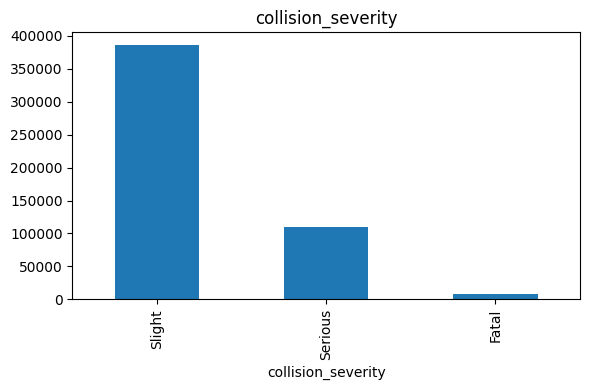

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df_collision_cut['collision_severity'].value_counts()
counts.index = counts.index.map({1: 'Fatal', 2: 'Serious', 3: 'Slight'})
print(counts.div(counts.sum()).mul(100).round(1))
counts.plot(kind='bar', figsize=(6, 4))
plt.title('collision_severity')
plt.tight_layout()
plt.show()


Distribuzione del target `collision_severity`

Il dataset è fortemente sbilanciato. 'Fatal' presente solo nell'1% dei casi.

Gestiamo lo sbilanciamento utilizzando la nuova variagile target collision_severity_coarse


### Distribuzione della nuova variabile target `collision_severity_coarse`

collision_severity_coarse
Slight          76.700
Serious/Fatal   23.300
Name: count, dtype: float64


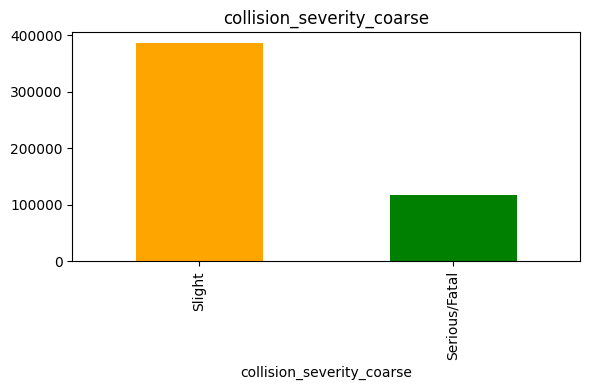

In [58]:
counts = df_collision_merge['collision_severity_coarse'].value_counts()
counts.index = counts.index.map({2: 'Serious/Fatal', 3: 'Slight'})
print(counts.div(counts.sum()).mul(100).round(1))
counts.plot(kind='bar', figsize=(6, 4), color=['orange', 'green'])
plt.title('collision_severity_coarse')
plt.tight_layout()
plt.show()

categoriche


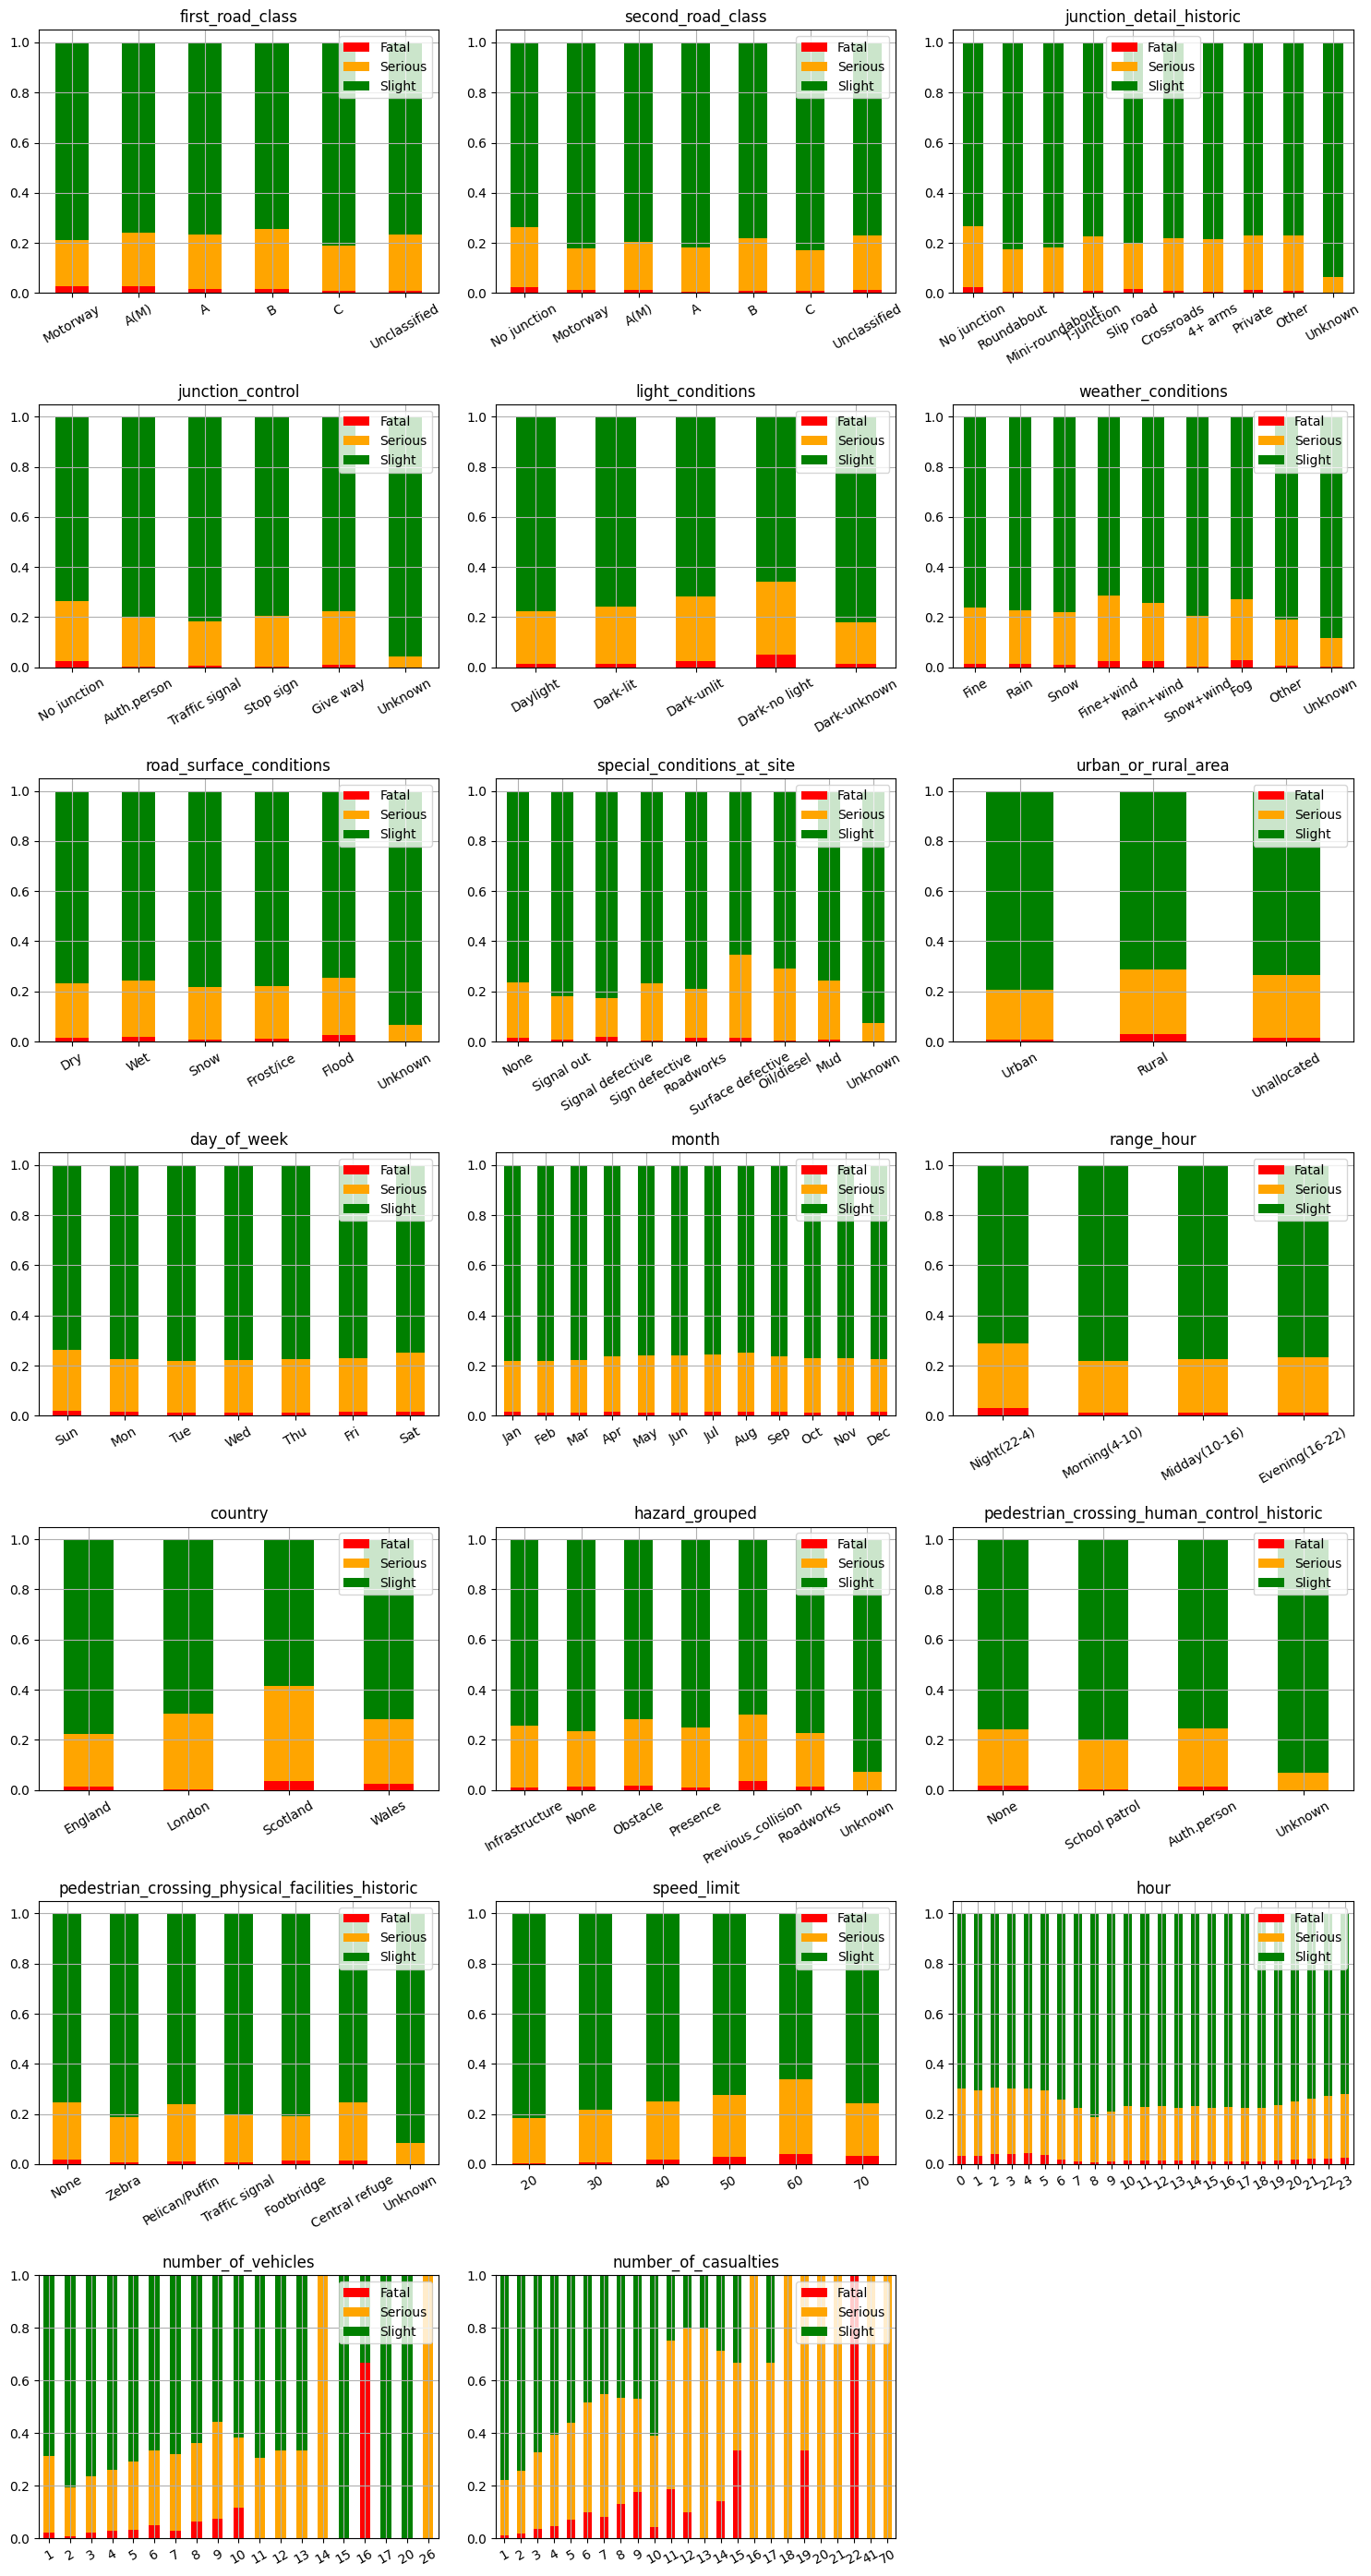

In [59]:
label_maps = {
    'first_road_class': {1:'Motorway', 2:'A(M)', 3:'A', 4:'B', 5:'C', 6:'Unclassified'},
    'second_road_class': {0:'No junction', 1:'Motorway', 2:'A(M)', 3:'A', 4:'B', 5:'C', 6:'Unclassified', 9:'Unknown'},
    'light_conditions': {1:'Daylight', 4:'Dark-lit', 5:'Dark-unlit', 6:'Dark-no light', 7:'Dark-unknown'},
    'weather_conditions': {1:'Fine', 2:'Rain', 3:'Snow', 4:'Fine+wind', 5:'Rain+wind', 6:'Snow+wind', 7:'Fog', 8:'Other', 9:'Unknown'},
    'road_surface_conditions': {1:'Dry', 2:'Wet', 3:'Snow', 4:'Frost/ice', 5:'Flood', 9:'Unknown'},
    'junction_detail_historic': {0:'No junction', 1:'Roundabout', 2:'Mini-roundabout', 3:'T-junction', 5:'Slip road', 6:'Crossroads', 7:'4+ arms', 8:'Private', 9:'Other', 99:'Unknown'},
    'junction_control': {0:'No junction', 1:'Auth.person', 2:'Traffic signal', 3:'Stop sign', 4:'Give way', 9:'Unknown'},
    'urban_or_rural_area': {1:'Urban', 2:'Rural', 3:'Unallocated'},
    'day_of_week': {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'},
    'special_conditions_at_site': {0:'None', 1:'Signal out', 2:'Signal defective', 3:'Sign defective', 4:'Roadworks', 5:'Surface defective', 6:'Oil/diesel', 7:'Mud', 9:'Unknown'},
    'pedestrian_crossing_human_control_historic': {0:'None', 1:'School patrol', 2:'Auth.person', 9:'Unknown'},
    'pedestrian_crossing_physical_facilities_historic': {0:'None', 1:'Zebra', 4:'Pelican/Puffin', 5:'Traffic signal', 7:'Footbridge', 8:'Central refuge', 9:'Unknown'},
    'range_hour': {0:'Night(22-4)', 1:'Morning(4-10)', 2:'Midday(10-16)', 3:'Evening(16-22)'},
    'month': {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'},
}

severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}

all_cols = ['first_road_class', 'second_road_class', 'junction_detail_historic',
            'junction_control', 'light_conditions', 'weather_conditions',
            'road_surface_conditions', 'special_conditions_at_site',
            'urban_or_rural_area', 'day_of_week', 'month', 'range_hour',
            'country', 'hazard_grouped',
            'pedestrian_crossing_human_control_historic',
            'pedestrian_crossing_physical_facilities_historic',
            'speed_limit', 'hour', 'number_of_vehicles', 'number_of_casualties']

ncols = 3
nrows = -(-len(all_cols) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows*4))
axes = axes.flatten()

for kk, k in enumerate(all_cols):
    pivot = df_collision_cut.groupby(k)['collision_severity']\
        .value_counts(normalize=True).unstack().fillna(0)
    pivot.columns = [severity_map[c] for c in pivot.columns]
    if k in label_maps:
        pivot.index = pivot.index.map(lambda x: label_maps[k].get(x, x))
    pivot.plot(kind='bar', stacked=True, ax=axes[kk], color=['red', 'orange', 'green'])
    axes[kk].tick_params(axis='x', labelrotation=30)
    axes[kk].set_title(k)
    axes[kk].set_xlabel('')
    axes[kk].grid()

for kk in range(len(all_cols), len(axes)):
    axes[kk].set_visible(False)

plt.tight_layout()
plt.show()

## Analisi variabili categoriche

**`first_road_class`** — La classe della strada riflette direttamente la velocità consentita
e la complessità del traffico. Le autostrade (Motorway) mostrano la proporzione più alta di
Fatal: sono strade ad alta velocità (70mph) dove gli impatti sono più violenti.
Scendendo verso strade locali (B, C, Unclassified) la severità diminuisce progressivamente.
Il trend è chiaro, ma unendo le classi 1-2 non emerge una differenza significativa tra le categorie → **Da valutare**

**`second_road_class`** — Indica la classe della strada secondaria all'incrocio. Le distribuzioni
sono quasi identiche tra tutte le categorie — non emerge un trend progressivo come in
`first_road_class`. L'informazione è parzialmente ridondante con `junction_detail_historic`.
→ **VALUTA con tabella di contingenza**

**`junction_detail_historic`** — Descrive il tipo di punto stradale dove è avvenuto l'incidente.
Gli incidenti su strada dritta (No junction) e sulle rampe autostradali (Slip road) mostrano
più Fatal e Serious — in questi punti le velocità sono più alte e non ci sono obblighi di
rallentamento. Alle rotatorie e agli incroci (T-junction, Crossroads) invece le auto rallentano,
quindi gli incidenti tendono ad essere meno gravi. Emerge una differenza tra le categorie → **TIENI**

**`junction_control`** — Indica come è controllato l'incrocio (semaforo, stop, precedenza ecc.).
"No junction" mostra più Serious/Fatal rispetto agli incroci controllati — come emerso già nell'analisi di
`junction_detail_historic`. Tra i tipi di controllo le differenze sono però piccole.
→ **VALUTA con tabella di contingenza con la target**, potrebbe essere ridondante con `junction_detail_historic`

**`light_conditions`** — La variabile più informativa visivamente. Gli incidenti al buio
senza illuminazione stradale (Dark-no light) mostrano chiaramente più Fatal e Serious rispetto
agli incidenti di giorno (Daylight). Ha senso: di notte la visibilità è ridotta, le reazioni
sono più lente e gli impatti più violenti. Anche Dark-unlit mostra più severità rispetto a
Dark-lit (buio con illuminazione) → la presenza dei lampioni fa differenza. → **TIENI** ✓✓

**`weather_conditions`** — Le condizioni meteo mostrano differenze limitate. Snow e Rain+wind
hanno leggermente più Serious rispetto al tempo Fine, ma le distribuzioni sono abbastanza
simili tra tutte le categorie. Sorprendentemente il maltempo non sembra aumentare
drasticamente la severità — forse perché con brutto tempo i guidatori rallentano.
→ **Rimuovi**

**`road_surface_conditions`** — Le condizioni del fondo stradale non mostrano differenze significative.
 → **Rimuovi**

**`special_conditions_at_site`** — Descrive condizioni eccezionali del sito (semaforo guasto,
lavori stradali, fondo difettoso ecc.).  Con l'83% di "None" e differenze piccole tra le altre categorie,
il potere predittivo è limitato. → **Rimuovi**

**`urban_or_rural_area`** — Una delle variabili più informative. Le strade rurali -Unallocated si comporta come rural- mostrano chiaramente più Fatal e Serious rispetto alle strade urbane — in campagna i limiti di velocità
sono più alti, le strade più strette e i soccorsi più lontani. In città invece il traffico
rallenta naturalmente e i soccorsi arrivano prima. → **TIENI** ✓✓

**`day_of_week`** — Le distribuzioni sono quasi identiche per tutti i giorni della settimana.
Non emerge un pattern chiaro tra giorni feriali e weekend. → **POCO INFORMATIVA**,


**`month`** — Le distribuzioni sono simili per tutti i mesi, con lievi variazioni invernali
(Nov-Dec leggermente più Serious). La stagionalità non sembra un forte predittore della
severità. → **POCO INFORMATIVA**

**`range_hour`** — La fascia notturna (Night 22-4) mostra chiaramente più Fatal e Serious
rispetto alle altre fasce orarie — di notte la visibilità è ridotta, ci sono meno veicoli
ma le velocità sono più alte. La mattina (Morning 4-10) mostra più Serious rispetto al
pomeriggio (Midday, Evening). → **TIENI** ✓

**`country`** — Scotland mostra chiaramente più Fatal e Serious rispetto alle altre nazioni,
mentre London ha la proporzione più alta di Slight. Ha senso: la Scozia ha molte strade
rurali strette e ad alta velocità, mentre Londra è un ambiente urbano densamente trafficato
dove le velocità sono naturalmente basse. → **TIENI** ✓

**`hazard_grouped`** — Descrive la presenza di ostacoli o pericoli sulla carreggiata.
"Previous_collision" mostra più Fatal — logico, un incidente precedente sulla strada crea
condizioni di pericolo aggiuntive. "Unknown" mostra pochissimi incidenti. Le altre categorie
(None, Obstacle, Presence, Roadworks) sono simili tra loro. → **VALUTA con tabella di contingenza**

**`pedestrian_crossing_human_control_historic`** — Indica se c'era un operatore umano
a controllare il passaggio pedonale (es. sorvegliante scolastico). "Unknown" mostra più
Serious/Fatal, le altre categorie sono simili. Con la maggior parte degli incidenti che
cade in "None" (nessun controllo), la variabile ha poco potere discriminante.
→ **POCO INFORMATIVA**

**`pedestrian_crossing_physical_facilities_historic`** — Descrive le infrastrutture fisiche
per i pedoni presenti sul luogo dell'incidente (strisce pedonali, semafori pedonali,
sottopassaggi ecc.). Le distribuzioni sono quasi identiche tra tutte le categorie — la
presenza o assenza di infrastrutture pedonali non sembra influenzare la severità
dell'incidente in modo significativo. → **POCO INFORMATIVA**


speed_limit — Trend chiarissimo: a 20-30mph domina Slight, a 60-70mph Fatal e Serious aumentano drasticamente. TIENI ✓✓

hour — Le ore notturne (0-5) hanno più Fatal e Serious rispetto al pomeriggio. Il trend c'è ma è meno netto rispetto a range_hour. Dato che range_hour cattura già questa informazione in modo più pulito, potresti tenere solo uno dei due. VALUTA se tenere hour o range_hour

number_of_vehicles — Fino a 6-7 veicoli c'è un trend crescente di Serious. Valori alti (15+) mostrano picchi di Fatal ma sono pochissimi casi — poco affidabili statisticamente. MEDIAMENTE INFORMATIVA

number_of_casualties — Trend molto chiaro: più vittime → più Serious e Fatal. Con 10+ vittime quasi tutto è Serious/Fatal. Ha senso logico: più persone coinvolte → incidente più grave. TIENI



# VARIABILI SELEZIONATE per il modello



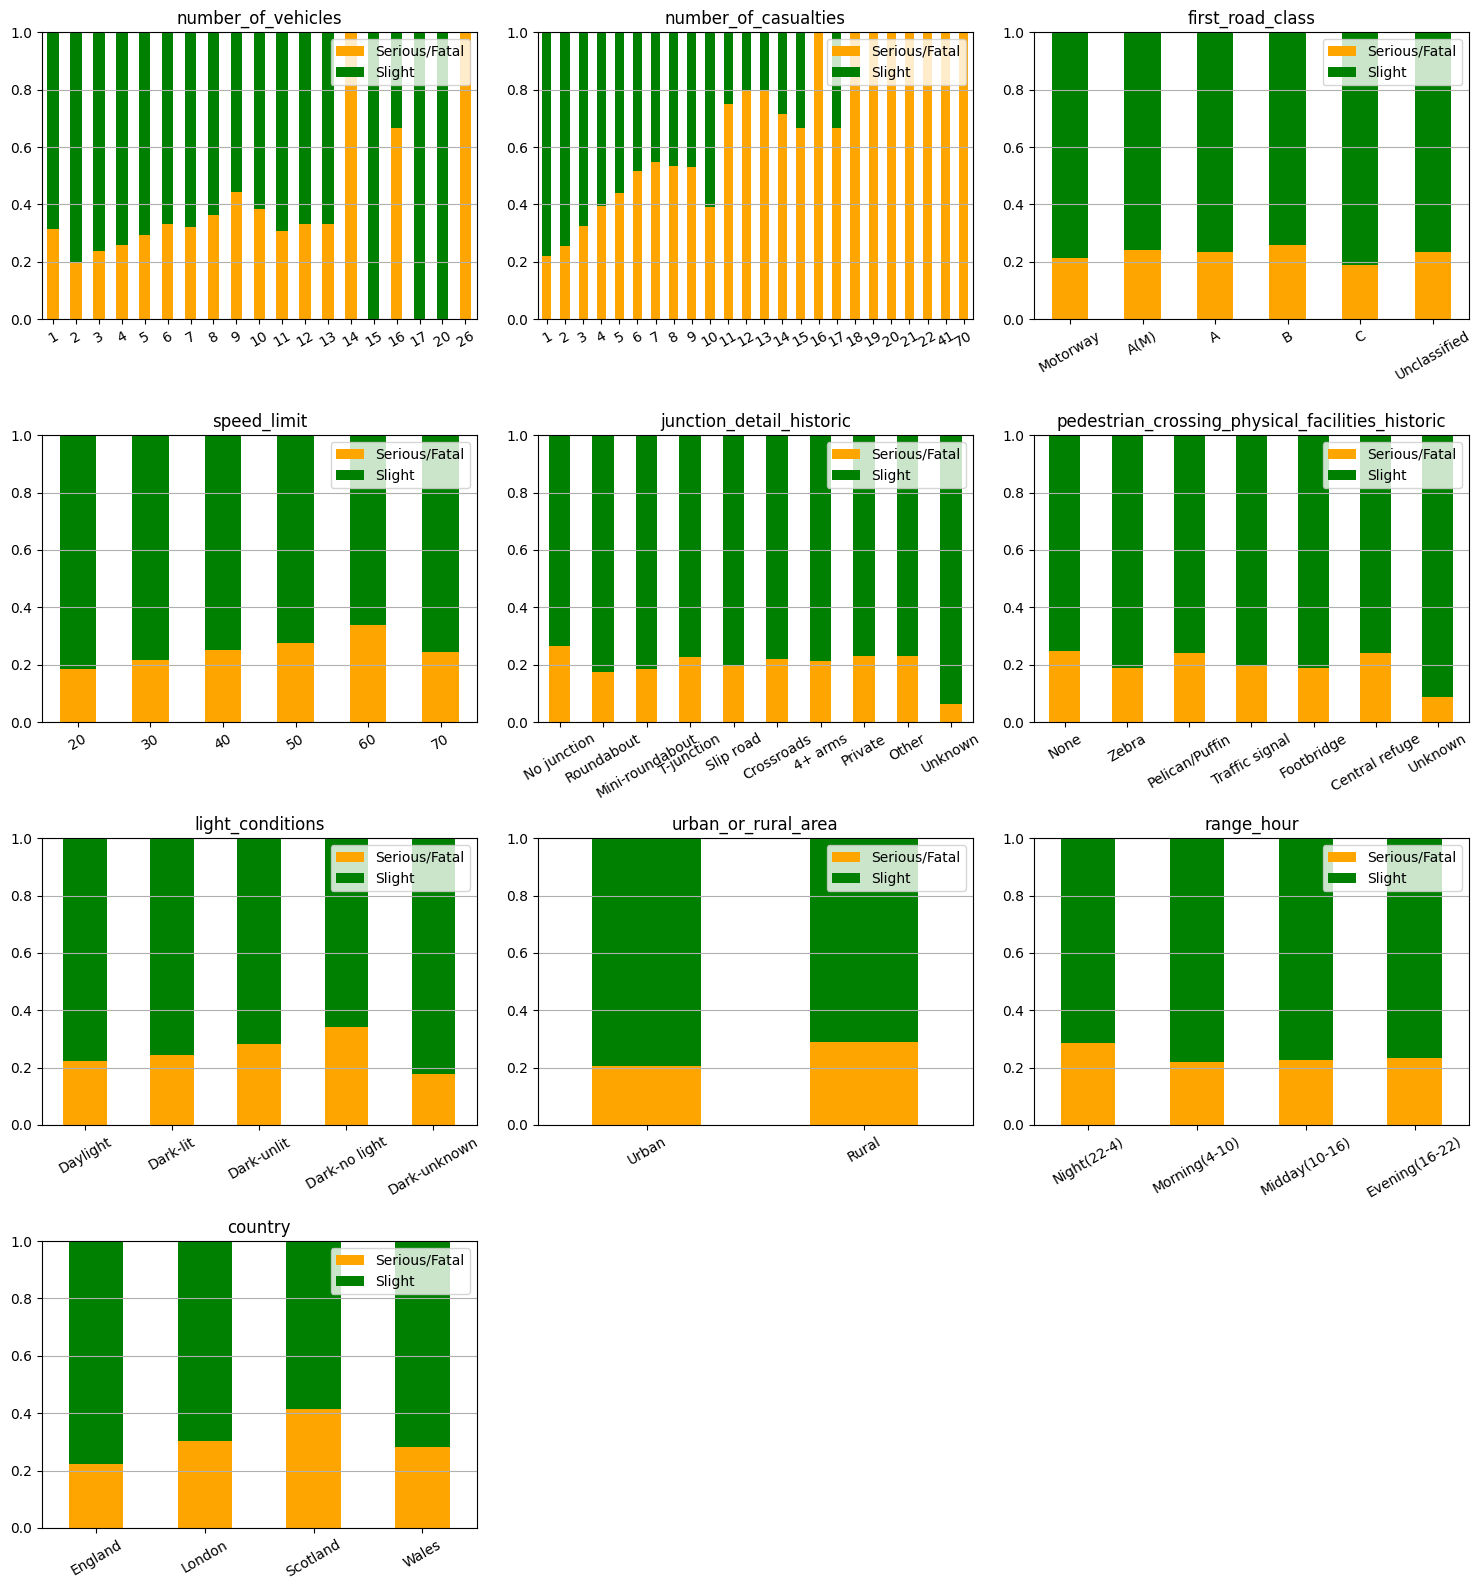

In [161]:
# =============================================
# ISTOGRAMMI STACKED PER collision_severity_coarse
# =============================================

label_maps = {
    'first_road_class':    {1:'Motorway', 2:'A(M)', 3:'A', 4:'B', 5:'C', 6:'Unclassified'},
    'light_conditions':    {1:'Daylight', 4:'Dark-lit', 5:'Dark-unlit', 6:'Dark-no light', 7:'Dark-unknown'},
    'weather_conditions':  {1:'Fine', 2:'Rain', 3:'Snow', 4:'Fine+wind', 5:'Rain+wind', 6:'Snow+wind', 7:'Fog', 8:'Other', 9:'Unknown'},
    'junction_control':    {0:'No junction', 1:'Auth.person', 2:'Traffic signal', 3:'Stop sign', 4:'Give way', 9:'Unknown'},
    'junction_detail_historic': {0:'No junction', 1:'Roundabout', 2:'Mini-roundabout', 3:'T-junction', 5:'Slip road', 6:'Crossroads', 7:'4+ arms', 8:'Private', 9:'Other', 99:'Unknown'},
    'road_surface_conditions': {1:'Dry', 2:'Wet', 3:'Snow', 4:'Frost/ice', 5:'Flood', 9:'Unknown'},
    'urban_or_rural_area': {1:'Urban', 2:'Rural', 3:'Unallocated'},
    'pedestrian_crossing_physical_facilities_historic': {0:'None', 1:'Zebra', 4:'Pelican/Puffin', 5:'Traffic signal', 7:'Footbridge', 8:'Central refuge', 9:'Unknown'},
    'range_hour':          {0:'Night(22-4)', 1:'Morning(4-10)', 2:'Midday(10-16)', 3:'Evening(16-22)'},
}

coarse_map = {2: 'Serious/Fatal', 3: 'Slight'}

plot_cols = [
    'number_of_vehicles',
    'number_of_casualties',
    'first_road_class',
    'speed_limit',
    'junction_detail_historic',
    'pedestrian_crossing_physical_facilities_historic',
    'light_conditions',
    'urban_or_rural_area',
    'range_hour',
    'country',
]

# flag separate (vedi tabella)
flag_cols = [
    'flag_driver/rider',
    'flag_passenger',
    'flag_pedestrian',
    'flag_age_<10',
    'flag_age_11-55',
    'flag_age_>55',
    'flag_pedestrian_age_>55',
    'flag_moto125',
    'flag_agricolo',
    'flag_tram',
    'flag_van',
    'flag_moto500'
]

ncols = 3
nrows = -(-len(plot_cols) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for kk, k in enumerate(plot_cols):
    pivot = (
        df_collision_merge
        .groupby(k)['collision_severity_coarse']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )
    pivot.columns = [coarse_map.get(c, str(c)) for c in pivot.columns]

    if k in label_maps:
        pivot.index = pivot.index.map(lambda x: label_maps[k].get(x, x))

    color_order = ['Serious/Fatal', 'Slight']
    colors = ['orange', 'green']
    cols_present = [c for c in color_order if c in pivot.columns]
    colors_present = [colors[color_order.index(c)] for c in cols_present]

    pivot[cols_present].plot(
        kind='bar', stacked=True, ax=axes[kk],
        color=colors_present
    )
    axes[kk].tick_params(axis='x', labelrotation=30)
    axes[kk].set_title(k)
    axes[kk].set_xlabel('')
    axes[kk].set_ylim(0, 1)
    axes[kk].grid(axis='y')

for kk in range(len(plot_cols), len(axes)):
    axes[kk].set_visible(False)

plt.tight_layout()
plt.show()

## Decision tree -- modello baseline

Innanzitutto, ricodifico due variabile che entreranno tra le features

In [49]:
map_police = {
    1: 1, #yes
    2: 2, #no
    3: 2 #no
}

df_collision_merge['did_police_officer_attend_scene_of_accident'] = df_collision_merge['did_police_officer_attend_scene_of_accident'].map(map_police)

map_urban={
    1:1 , #urban
    2:2 , #rural
    3:2   #rural
}

df_collision_merge['urban_or_rural_area'] = df_collision_merge['urban_or_rural_area'].map(map_urban)

In questo primo modello includiamo le variabili prese da df_casualty e df_vehicle e le variabile selezionate da df_collision

CV con dati dal 2020 al 2023 (non tocchiamo il 2024). Sarà quindi 4-fold cv

In [50]:


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. DATI

target = "collision_severity_coarse"

feature_cols = [
    'number_of_vehicles',
    'number_of_casualties',
    'range_hour',
    'urban_or_rural_area',  
    'speed_limit', 
    'light_conditions', 
    'country', 
    'did_police_officer_attend_scene_of_accident', 
    'flag_pedestrian', 
    'flag_driver/rider',
    'flag_moto500',
    'flag_age_<10',  
    'flag_age_>55', 
    'flag_moto125', 
    'flag_agricolo', 
    'flag_tram', 
    'flag_van',
    'junction_detail_historic',
    'junction_control',
    'pedestrian_crossing_physical_facilities_historic'
    ]

categorical_cols = [ 
    'light_conditions', 
    'country', 
    'junction_detail_historic',
    'junction_control',
    'pedestrian_crossing_physical_facilities_historic',
    'range_hour'
]


# colonne numeriche = tutte le altre
numeric_cols = [col for col in feature_cols if col not in categorical_cols]

# =========================
# 3. PREPROCESSING


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# =========================
# 4. MODELLO


model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,        
        random_state=42,
        class_weight="balanced"
    ))
])

# =========================
# 5. TRAIN / TEST SPLIT


df = df_collision_merge.copy()
df = df.sort_values("collision_year")

years = [2020, 2021, 2022, 2023]

results = []
models = {}

for test_year in years:
    
    train = df[df["collision_year"] != test_year]
    test  = df[df["collision_year"] == test_year]
    
    X_train = train[feature_cols]
    y_train = train[target]
    
    X_test = test[feature_cols]
    y_test = test[target]
    
 
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    # metriche
    acc = accuracy_score(y_test, y_pred)
    rec_label2 = recall_score(y_test, y_pred, pos_label=2)
    
    results.append({
        "test_year": test_year,
        "accuracy": acc,
        "recall_label2": rec_label2
    })
    
    # salva modello
    models[test_year] = model

# =========================
# RISULTATI
# =========================
results_df = pd.DataFrame(results)
print(results_df)

   test_year  accuracy  recall_label2
0       2020     0.689          0.495
1       2021     0.689          0.497
2       2022     0.678          0.531
3       2023     0.683          0.534


Tra i vari modelli non c'è molta differenza. Accuracy tra il 68 e 69% e recall per la classe 2 tra 50 e 53%
Quello con le metriche migliori sembra il 2023, guardiamo l'albero

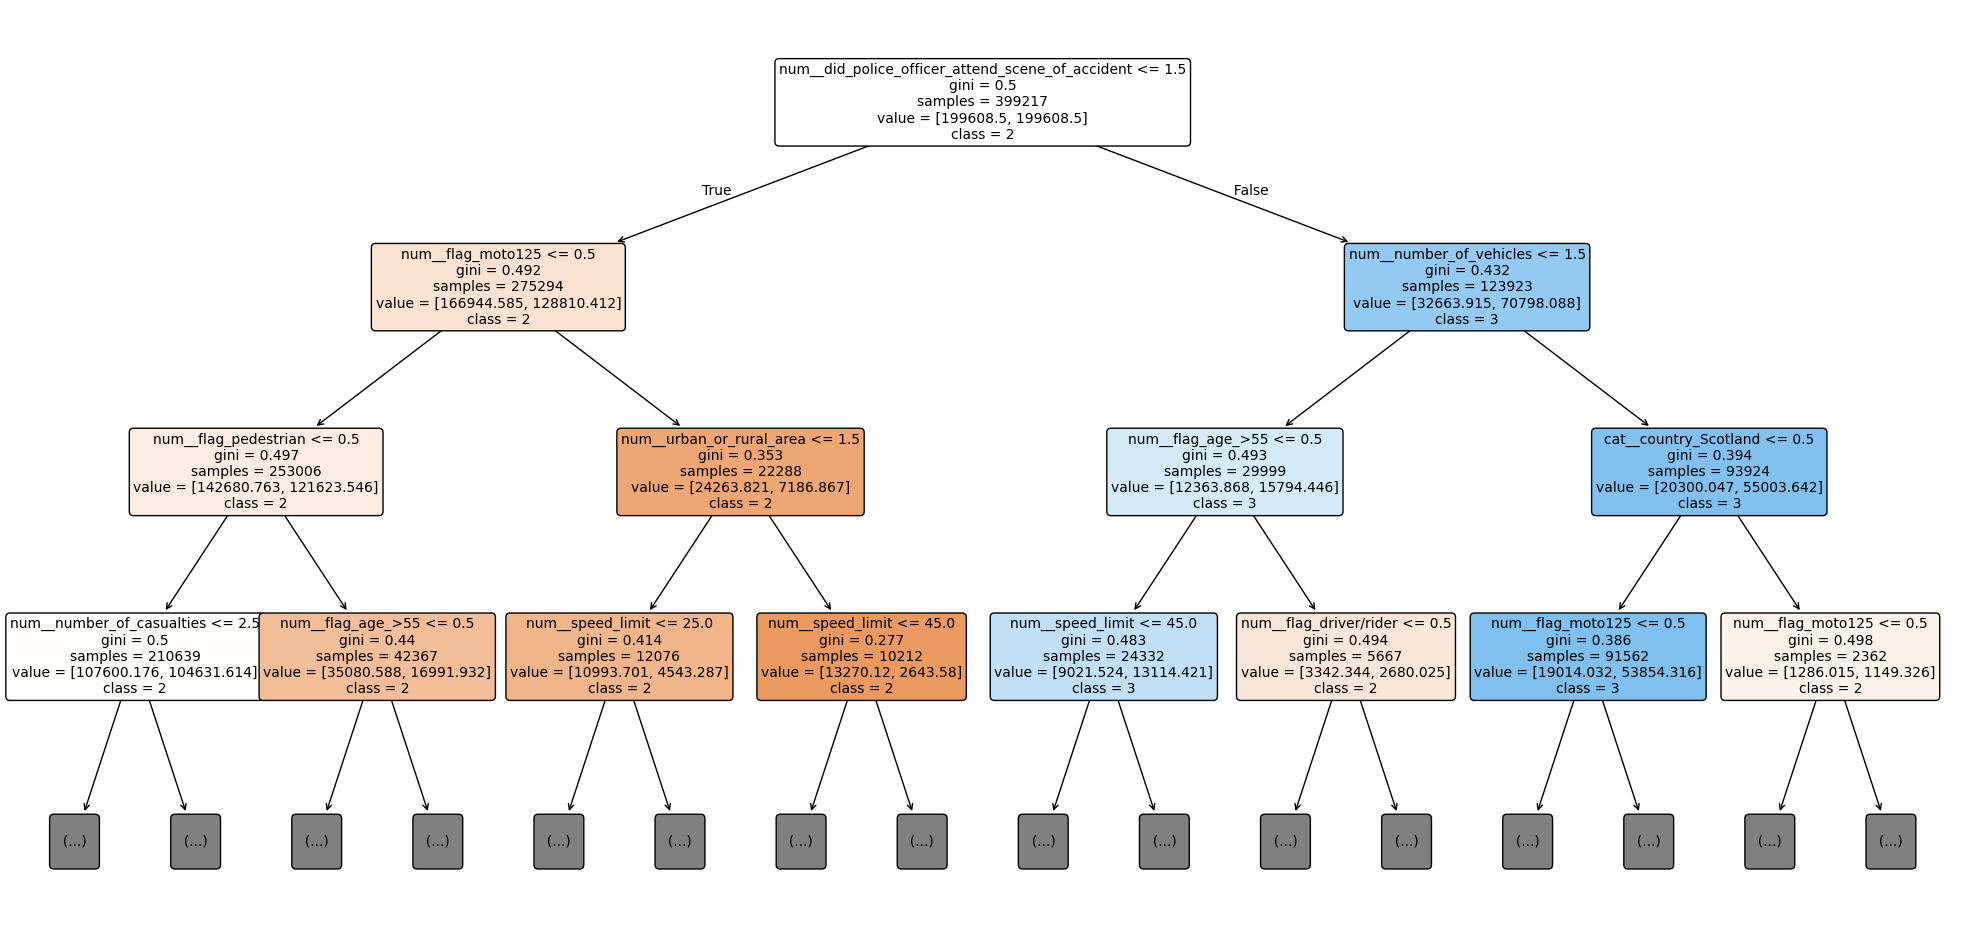

In [157]:
pipe = models[2023]

model = pipe.named_steps["classifier"]
preprocess = pipe.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

plt.figure(figsize=(25,12))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=["2", "3"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.show()

Dal grafico emerge come le prime variabili per lo split sono : did_police_officer_attend_scene_of_accident, numero di veicoli, moto125, pedestrian

In [163]:
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(fi[fi['importance']>0.01])

                                             feature  importance
40  num__did_police_officer_attend_scene_of_accident       0.459
46                                 num__flag_moto125       0.163
41                              num__flag_pedestrian       0.112
36                           num__number_of_vehicles       0.093
37                         num__number_of_casualties       0.060
45                                 num__flag_age_>55       0.036
39                                  num__speed_limit       0.029
7                              cat__country_Scotland       0.022
38                          num__urban_or_rural_area       0.021


In [159]:
df_collision_merge[df_collision_merge["collision_year"] == 2023] \
    .groupby("flag_moto500")["collision_severity_coarse"] \
    .value_counts()

flag_moto500  collision_severity_coarse
0             3                            77205
              2                            22696
1             2                             2264
              3                             2093
Name: count, dtype: int64

In [162]:
df_pivot=pd.pivot_table(df_collision_merge,index="did_police_officer_attend_scene_of_accident",columns="flag_moto500",aggfunc="count",values="collision_index")
df_pivot.div(df_pivot.sum(axis=0),axis=1)

flag_moto500,0,1
did_police_officer_attend_scene_of_accident,,
1,0.681,0.857
2,0.319,0.143


Nonostante flag_moto500 sia molto esplicativa, notiamo che nell'85% dei casi in cui è presente una moto la polizia occorre sulla scena del crimine. Il modello quindi utilizza solo una delle due variabile per lo split

Come prossimo modello testeremo un CATBOOST in cui includiamo le variabili con feature importance più alta nel tree a cui aggiungiamo alcune variabili sottoforma di interazione

In [40]:
#Abbiamo creato una nuova variabile che combina i mezzi a due ruote e i mezzi pesanti 
#Se l'incidente avviene tra almeno un mezzo leggero e almeno un mezzo pesante allora la variabile prende valore 1

df_collision_merge['flag_moto_heavy'] = (
    (
        (df_collision_merge['flag_moto125'] == 1) |
        (df_collision_merge['flag_moto500'] == 1)
    ) &
    (
        (df_collision_merge['flag_van'] == 1) |
        (df_collision_merge['flag_tram'] == 1) |
        (df_collision_merge['flag_agricolo'] == 1)
    )
).astype(int)

df_collision_merge['flag_dark_pedestrian'] = (
    (df_collision_merge['light_conditions'].isin([5,6])) &
    (df_collision_merge['flag_pedestrian'] == 1)
).astype(int)

## CATBOOST - hyperparameter tuning

Data la difficoltà dal punto di vista computazionale di fare una random search o una grid search, abbiamo testato alcuni valori degli hyperparametri manualmente

hyperparametri : depth , learning rate , iterations, l2_leaf_reg, threshold

Train su dati dal 2020 al 2022 e validazione sui dati del 2023

primo modello :  "depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 7, "iterations": 1000, "threshold"= 0.46, 0.5 \
variazione nel secondo modello: "depth":8


In [180]:
from sklearn.model_selection import ParameterSampler
from catboost import CatBoostClassifier

target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]


# =========================
# SPLIT
# =========================
df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2022]
test_df  = df[df["collision_year"] == 2023]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# PARAMETRI FISSI (SCELTI MANUALMENTE)
# =========================
params = {
    "depth": 6,       #testeremo vari valori di questo
    "learning_rate": 0.05, #convergenza più lenta
    "l2_leaf_reg": 7,      #meno overfitting (rende più stabile la previsione tra i vari fold)
    "iterations": 1000,
    "loss_function": "Logloss",
    "auto_class_weights": "Balanced",
    "verbose": 0,
    "thread_count": -1
}

# =========================
# MODELLO
# =========================
model = CatBoostClassifier(**params)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    verbose=0
)

# =========================
# PREDIZIONE
# =========================
probs = model.predict_proba(X_test)[:, 0]

thresholds = [0.46, 0.5]

results = []

for t in thresholds:
    
    y_pred = np.where(probs >= t, 2, 3)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=2)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "recall": rec
    })

# =========================
# RISULTATI
# =========================
results_df = pd.DataFrame(results)

print(results_df) #se abbasso la threshold l'accuracy si abbassa ma migliora la recall

   threshold  accuracy  recall
0      0.460     0.603   0.709
1      0.500     0.659   0.615


In [181]:
target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]


# =========================
# SPLIT
# =========================
df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2022]
test_df  = df[df["collision_year"] == 2023]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# PARAMETRI FISSI (SCELTI MANUALMENTE)
# =========================
params = {
    "depth": 8,       #nuovo valore
    "learning_rate": 0.05, 
    "l2_leaf_reg": 7,      
    "iterations": 1000,
    "loss_function": "Logloss",
    "auto_class_weights": "Balanced",
    "verbose": 0,
    "thread_count": -1
}

# =========================
# MODELLO
# =========================
model = CatBoostClassifier(**params)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    verbose=0
)

# =========================
# PREDIZIONE
# =========================
probs = model.predict_proba(X_test)[:, 0]

thresholds = [0.46, 0.5]

results = []

for t in thresholds:
    
    y_pred = np.where(probs >= t, 2, 3)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=2)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "recall": rec
    })

# =========================
# RISULTATI
# =========================
results_df = pd.DataFrame(results)

print(results_df) #risultati simili

   threshold  accuracy  recall
0      0.460     0.607   0.703
1      0.500     0.660   0.610


Ora provo a modificare il valore di learning rate = 0.1 e l2_leaf_reg = 5 \
Per threshold fissiamo come valore 0.46 e per depth = 6

In [182]:

target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]

# SPLIT
# =========================
df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2022]
test_df  = df[df["collision_year"] == 2023]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# PARAMETRI FISSI (SCELTI MANUALMENTE)
# =========================
params = {
    "depth": 6,       #nuovo valore
    "learning_rate": 0.1, #convergenza più lenta
    "l2_leaf_reg": 5,      #meno overfitting
    "iterations": 1000,
    "loss_function": "Logloss",
    "auto_class_weights": "Balanced",
    "verbose": 0,
    "thread_count": -1
}

# =========================
# MODELLO
# =========================
model = CatBoostClassifier(**params)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    verbose=0
)

# =========================
# PREDIZIONE
# =========================
probs = model.predict_proba(X_test)[:, 0]


threshold = 0.46

y_pred = np.where(probs >= threshold, 2, 3)

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=2)

print({
    "threshold": threshold,
    "accuracy": acc,
    "recall": rec
}) 

{'threshold': 0.46, 'accuracy': 0.6066201154827447, 'recall': 0.7019230769230769}


Notiamo valori più o meno costanti, non c'è un'unica scelta che è possibile prendere \
Lanciamo una cv del modello catboost con dati dal 2020 al 2023 con gli hyperparametri scelti \
Vogliamo verificare la stabilità delle performance tra i diversi fold

In [185]:
target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]

#parametri
params = {
    "iterations": 1000,          # alto → ci pensa early stopping
    "depth": 6,
    "learning_rate": 0.1,  #stabile, non troppo lento (non richiede un gran numero di iterazioni)
    "l2_leaf_reg": 5,      #più basso rischio overfitting
}

df = df_collision_merge.copy()
df = df.sort_values("collision_year")
train_df = df[df["collision_year"] <= 2023]

results = []

for val_year in [2020, 2021, 2022, 2023]:
    
    train = train_df[train_df["collision_year"] != val_year]
    val   = train_df[train_df["collision_year"] == val_year]

    X_train = train[feature_cols]
    y_train = train[target]

    X_val = val[feature_cols]
    y_val = val[target]

    model = CatBoostClassifier(
        **params,
        loss_function="Logloss",
        auto_class_weights="Balanced",
        verbose=0
    )

    model.fit(
        X_train, 
        y_train,
        cat_features=categorical_cols,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,   # se dopo 50 iterazioni la performance sul validation set non migliora si ferma
        use_best_model=True
    )

    probs = model.predict_proba(X_val)[:,0]
    y_pred = np.where(probs >= 0.46, 2, 3)

    acc = accuracy_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred, pos_label=2)  

    # salva risultati
    results.append({
        "year": val_year,
        "accuracy": acc,
        "recall_2": rec,
        "best_iteration": model.get_best_iteration()
    })


In [186]:
print(results) #accuracy 60/61% e recall tra 68 e 71%

[{'year': 2020, 'accuracy': 0.6059605916731543, 'recall_2': 0.6800364630811303, 'best_iteration': 216}, {'year': 2021, 'accuracy': 0.6033416759820749, 'recall_2': 0.6788382107390808, 'best_iteration': 343}, {'year': 2022, 'accuracy': 0.6023734953397984, 'recall_2': 0.6961700421094846, 'best_iteration': 253}, {'year': 2023, 'accuracy': 0.6033685664409446, 'recall_2': 0.709375, 'best_iteration': 215}]


## CATBOOST - test 2024

In [187]:
target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]

# PARAMETRI FINAL MODEL
# ---------------------------
final_params = {
    "iterations": 1000,          # valore stabile tra 215 e 343
    "depth": 6,
    "learning_rate": 0.1,
    "l2_leaf_reg": 5,
    "loss_function": "Logloss",
    "auto_class_weights": "Balanced",
    "verbose": 0
}

# ---------------------------
# SPLIT TEMPORALE
# ---------------------------
df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2023]
test_df  = df[df["collision_year"] == 2024]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# ---------------------------
# TRAIN MODELLO FINALE
# ---------------------------
model = CatBoostClassifier(**final_params)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,   # se dopo 50 iterazioni la performance sul validation set non migliora si ferma
    use_best_model=True
)

# ---------------------------
# PREDIZIONE
# ---------------------------
probs_class2 = model.predict_proba(X_test)[:, 0]  # classe 2
y_pred = np.where(probs_class2 >= 0.46, 2, 3)

# ---------------------------
# METRICHE
# ---------------------------
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=2)

print("Accuracy:", acc)
print("Recall (class 2):", rec)
print("Best iteration (train):", model.get_best_iteration()) #accuracy 0.60 e recall 0.69

Accuracy: 0.595658248040663
Recall (class 2): 0.7053332801467949
Best iteration (train): 221


In [ ]:
fi = model.get_feature_importance()
features = X_train.columns

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": fi
}).sort_values(by="importance", ascending=False)

print(feature_importance) #le feature aggiunte,come interazione, non danno un gran contributo)

                                        feature  importance
4   did_police_officer_attend_scene_of_accident      34.544
8                                  flag_moto125      16.346
1                            number_of_vehicles      12.407
0                          number_of_casualties       7.198
5                               flag_pedestrian       7.087
2                                   speed_limit       6.893
3                                       country       5.169
7                                  flag_age_>55       4.961
9                           urban_or_rural_area       4.158
6                       flag_pedestrian_age_>55       0.702
10                         flag_dark_pedestrian       0.421
11                              flag_moto_heavy       0.115


Ora valutiamo XGBoost, che dovrebbe essere meno costoso dal punto di vista computazionale, ma non sappiamo se performa uguale

In [55]:
#proviamo xg boost


from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# =========================
# FEATURE
# =============
target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]

numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# =========================
# PREPROCESSING
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# =========================
# SPLIT TEMPORALE
# =========================
df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2023]
test_df  = df[df["collision_year"] == 2024]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# =========================
# BINARIZZAZIONE TARGET
# =========================
y_train_bin = (y_train == 2).astype(int)
y_test_bin  = (y_test == 2).astype(int)

# =========================
# scale_pos_weight (IMPORTANTE)
# =========================
scale_pos = len(y_train_bin[y_train_bin == 0]) / len(y_train_bin[y_train_bin == 1])

# =========================
# MODELLO XGBOOST
# =========================
model = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.05,
    reg_lambda=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

# =========================
# PIPELINE
# =========================
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

# =========================
# TRAIN
# =========================
pipeline.fit(X_train, y_train_bin)

# =========================
# PREDIZIONE
# =========================
probs = pipeline.predict_proba(X_test)[:, 1]

threshold = 0.46
y_pred_bin = (probs >= threshold).astype(int)

# ritorno a 2 / 3
y_pred = np.where(y_pred_bin == 1, 2, 3)

# =========================
# METRICHE
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=2)

print("Accuracy:", acc)
print("Recall (class 2):", rec) #risultati simili

Accuracy: 0.5988585809545514
Recall (class 2): 0.6985121065858231


In [60]:
#feature importance
feature_names = pipeline.named_steps[
    "preprocess"
].get_feature_names_out()

# =========================
# ESTRAZIONE MODELLO XGBOOST
# =========================
xgb_model = pipeline.named_steps["model"]

# =========================
# FEATURE IMPORTANCE
# =========================
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
})

# ordinamento
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

                                             feature  importance
7   num__did_police_officer_attend_scene_of_accident       0.350
11                                 num__flag_moto125       0.201
8                               num__flag_pedestrian       0.104
2                              cat__country_Scotland       0.071
10                                 num__flag_age_>55       0.050
12                          num__urban_or_rural_area       0.045
5                            num__number_of_vehicles       0.043
4                          num__number_of_casualties       0.029
9                       num__flag_pedestrian_age_>55       0.028
0                               cat__country_England       0.024
6                                   num__speed_limit       0.021
13                         num__flag_dark_pedestrian       0.014
3                                 cat__country_Wales       0.007
14                              num__flag_moto_heavy       0.007
1                        

In [62]:


# =========================
# FEATURE
# =============
target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]

numeric_cols = [c for c in feature_cols if c not in categorical_cols]

# =========================
# PREPROCESSING
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# =========================
# SPLIT TEMPORALE
# =========================
df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2023]
test_df  = df[df["collision_year"] == 2024]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# =========================
# BINARIZZAZIONE TARGET
# =========================
y_train_bin = (y_train == 2).astype(int)
y_test_bin  = (y_test == 2).astype(int)

# =========================
# scale_pos_weight (IMPORTANTE)
# =========================
scale_pos = len(y_train_bin[y_train_bin == 0]) / len(y_train_bin[y_train_bin == 1])

# =========================
# MODELLO XGBOOST
# =========================
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    reg_lambda=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42
)

# =========================
# PIPELINE
# =========================
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

# =========================
# TRAIN
# =========================
pipeline.fit(X_train, y_train_bin)

# =========================
# PREDIZIONE
# =========================
probs = pipeline.predict_proba(X_test)[:, 1]

threshold = 0.46
y_pred_bin = (probs >= threshold).astype(int)

# ritorno a 2 / 3
y_pred = np.where(y_pred_bin == 1, 2, 3)

# =========================
# METRICHE
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred, pos_label=2)

print("Accuracy:", acc)
print("Recall (class 2):", rec) #risultati simili

Accuracy: 0.5985316119571572
Recall (class 2): 0.6981132075471698


Dal momento che il modello XGBoost raggiunge la stessa performance per accuracy e recall, ma in un minor tempo, quindi il nostro modello definitivo è XGBoost

In [192]:
import joblib

In [ ]:
os.makedirs("modelli", exist_ok=True)

joblib.dump(pipeline, "modelli/xgboost_pipeline_2024.pkl")

['modelli/xgboost_pipeline_2024.pkl']

In [66]:
#lancio un decision tree con stesso numero di variabili e stesso train
target = "collision_severity_coarse"

feature_cols = [
    'number_of_casualties',  
    'number_of_vehicles',
    'speed_limit',  
    'country', 
    'did_police_officer_attend_scene_of_accident',
    'flag_pedestrian',
    'flag_pedestrian_age_>55',
    'flag_age_>55', 
    'flag_moto125', 
    'urban_or_rural_area',
    'flag_dark_pedestrian',
    'flag_moto_heavy'
]

categorical_cols = [  
    'country'
]

numeric_cols = [col for col in feature_cols if col not in categorical_cols]

# =========================
# 3. PREPROCESSING


preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# =========================
# 4. MODELLO


model = Pipeline([
    ("preprocess", preprocess),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,        
        random_state=42,
        class_weight="balanced"
    ))
])

df = df_collision_merge.copy()
df = df.sort_values("collision_year")

train_df = df[df["collision_year"] <= 2023]
test_df  = df[df["collision_year"] == 2024]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

# binarizzazione target (classe 2 vs resto)
y_train_bin = (y_train == 2).astype(int)
y_test_bin  = (y_test == 2).astype(int)


model.fit(X_train, y_train_bin)
y_pred_bin = model.predict(X_test)

# ritorno alle classi originali
y_pred = np.where(y_pred_bin == 1, 2, 3)

# =========================
# METRICHE
# =========================
acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test_bin, y_pred_bin)

print("Accuracy:", acc)
print("Recall (classe 2):", rec)

Accuracy: 0.674576674229889
Recall (classe 2): 0.5273445290996849
